In [1]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

from src.ua_sa_nsga2.individual     import Individual
from src.ua_sa_nsga2.inicialization import initialize_population
from src.ua_sa_nsga2.evaluation     import evaluate_population, genotype_to_registro
from src.ua_sa_nsga2.offspring      import create_offspring_population
from src.ua_sa_nsga2.selection      import generational_selection
from src.ua_sa_nsga2.utils          import collect_generation_stats, plot_optimization_progress


import pandas as pd
from src.processing import find_pareto_front
from src.visualization import display_pareto_front, display_two_pareto_fronts, display_pareto_fronts3, display_fitness_landscape_with_2pareto
from src.metrics import calculate_gamma_convergence_metric, print_gamma_metric

/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Parâmetros NSGA-II
config = {
    # definindo o algoritmo
    'population_size': 100,
    'n_generations': 200,
    'k_tournament': 2,
    'crossover_prob': 0.9,
    'crossover_eta': 15,
    'mutation_prob': 1/6,  # 1/n_var
    'mutation_eta': 20,
    'seed': 42,
    'track_progress': True,

    # definindo o problema
    'n_objetivos': 2,
    'fitness_cols': ["fitness1_c1", "fitness2_c1"],
    'maximize': True,
    'n_restricoes': 0,

    # definindo o genótipo
    'tamanho_genotipo': 6,
    'limite_inferior': np.array([0, 0, 0, 0, 0, 0]),
    'limite_superior': np.array([9, 9, 9, 9, 9, 9]),
    'tipo_variavel_genotipo': int
}

In [3]:
df_mcmc1 = pd.read_parquet('data/df_mcmc1.parquet')
df_mcmc2 = pd.read_parquet('data/df_mcmc2.parquet')

print(df_mcmc1.shape)
print(df_mcmc2.shape)
display(df_mcmc2.head())

(1000, 4)
(1000, 4)


,index_linha,regiao,erro1_c1,erro2_c1
0,0,1,0.441198,-3.528011
1,1,1,2.860782,1.527073
2,2,1,2.758490,-0.195303
3,3,1,-0.355703,-3.481056
4,4,1,3.966358,1.404615


In [4]:
df1 = pd.read_parquet('data/df_surrogate1.parquet')
df2 = pd.read_parquet('data/df_surrogate2.parquet')

print(df1.shape)
print(df2.shape)
display(df2.head())

(1000000, 45)
(1000000, 49)


,registro,fitness1_eq0,fitness1_eq1,fitness1_eq2,fitness1_eq3,fitness1_eq4,fitness1_eq5,fitness1_eq6,fitness1_eq7,fitness1_eq8,...,erro_abs1_c3,fitness2_c1,fitness2_c2,fitness2_c3,erro2_c1,erro_abs2_c1,erro2_c2,erro_abs2_c2,erro2_c3,erro_abs2_c3
0,0,0.000000e+00,10.0,7.0,4.0,5.0,5.0,0.0000,3.000000,2.000000,...,3.402582,11.550515,11.242739,12.287389,-2.064098,2.064098,-1.756321,1.756321,-2.800971,2.800971
1,1,5.714286e-12,10.0,7.0,4.0,5.0,5.0,0.0004,3.000000,1.999998,...,3.249206,11.550515,11.242739,12.287389,-2.065560,2.065560,-1.757783,1.757783,-2.802434,2.802434
2,2,2.285714e-11,10.0,7.0,4.0,5.0,5.0,0.0008,2.999999,1.999994,...,3.250980,11.550515,11.242739,12.287389,-2.067021,2.067021,-1.759245,1.759245,-2.803895,2.803895
3,3,5.142857e-11,10.0,7.0,4.0,5.0,5.0,0.0012,2.999998,1.999986,...,3.252751,11.550515,11.242739,11.944605,-2.068481,2.068481,-1.760704,1.760704,-2.462571,2.462571
4,4,9.142857e-11,10.0,7.0,4.0,5.0,5.0,0.0016,2.999996,1.999975,...,3.254520,11.550515,11.242739,11.944605,-2.069939,2.069939,-1.762163,1.762163,-2.464029,2.464029


In [6]:
######### 1. População Inicial (initial population)
# Define random seed    
np.random.seed(config['seed'])

# Inicializando população de soluções    
population, _ = initialize_population(config)

# Avalia fitness da população inicial
evaluate_population(population, df1, config['fitness_cols'], config['maximize'])

In [7]:
population

[Individual([6, 1, 5, 4, 4, 8], fitness=[-1.431672989696261, -1.5605681059246708], rank=None),
 Individual([3, 0, 0, 7, 0, 0], fitness=[-4.140175570406517, -3.1237793804506744], rank=None),
 Individual([7, 6, 8, 0, 6, 0], fitness=[-3.111278606102496, -2.2021898592346965], rank=None),
 Individual([4, 6, 5, 4, 4, 3], fitness=[-1.9752875552825395, -3.322652612905597], rank=None),
 Individual([6, 7, 2, 2, 5, 8], fitness=[-2.935182028097164, -2.783599884716497], rank=None),
 Individual([9, 4, 3, 0, 6, 5], fitness=[-3.2205302419283166, -3.2165122922381233], rank=None),
 Individual([2, 2, 3, 3, 2, 2], fitness=[-2.192245205880025, -2.3230651794854853], rank=None),
 Individual([6, 7, 2, 4, 9, 0], fitness=[-2.912337270999848, -2.8882529874305454], rank=None),
 Individual([7, 5, 9, 6, 2, 3], fitness=[-3.3403481215230144, -2.433273948504672], rank=None),
 Individual([4, 2, 2, 0, 4, 8], fitness=[-1.792802453231119, -2.534283188765469], rank=None),
 Individual([3, 0, 2, 2, 5, 2], fitness=[-4.0367873

In [ ]:


    

    ############# Loop principal das gerações
    progress_stats = []
    for generation in tqdm(range(config['n_generations'])):

        ######### 2. População Descendente (offspring population)
        # Criar população descendente Qt
        offspring = create_offspring_population(population, config)

        # Avalia fitness da população descendente
        evaluate_population(offspring, df_landscape, config['fitness_cols'], config['maximize'])


        ######### 3. Seleção Geracional (generational selection)
        # Combinar Pt e Qt para formar Rt
        combined_population = population + offspring

        # Seleção geracional: selecionar N melhores para formar P(t+1)
        population = generational_selection(combined_population, config['population_size'])

        # Rastreamento de progresso
        if config['track_progress']:
            stats = collect_generation_stats(population, generation, config)
            progress_stats.append(stats)


    ######### Finalização
    # Extrair front de Pareto final (rank 1)
    pareto_front = [ind for ind in population if ind.rank == 1]
        
    # Converter para registros e criar dataframe
    registros = [genotype_to_registro(ind.genotype) for ind in pareto_front]
    df_pareto = df_landscape[df_landscape['registro'].isin(registros)].copy()
    
    print(f"\n✅ Otimização concluída!")
    print(f"Soluções encontradas no front: {len(pareto_front)}")
    print(f"Registros únicos no dataframe: {len(df_pareto)}")

    if config['track_progress']:
        df_progress = pd.DataFrame(progress_stats)
        plot_optimization_progress(df_progress)
    else:
        df_progress = None


    return df_pareto, pareto_front, df_progress

### 2.2. my NSGA-II
Implementação Própria do algoritmo NSGA-II seguindo o paper original de Deb et al. (2002)

In [8]:
from src.nsgaII import run_my_nsga2

/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3. Experimentos

### Problema 1. Landscape Real

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 10,344 pontos.
Isso representa 1.0344% do espaço de busca.


100%|██████████| 200/200 [00:14<00:00, 14.13it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 91


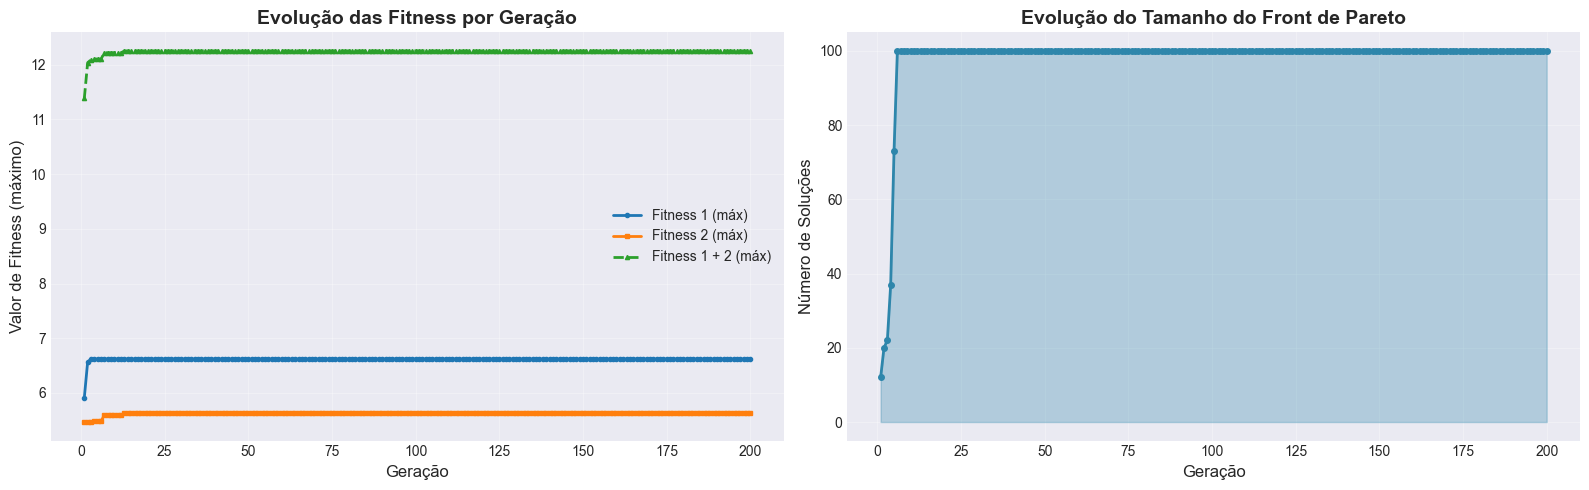


✅ Gráficos de progresso gerados com sucesso!

✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 100


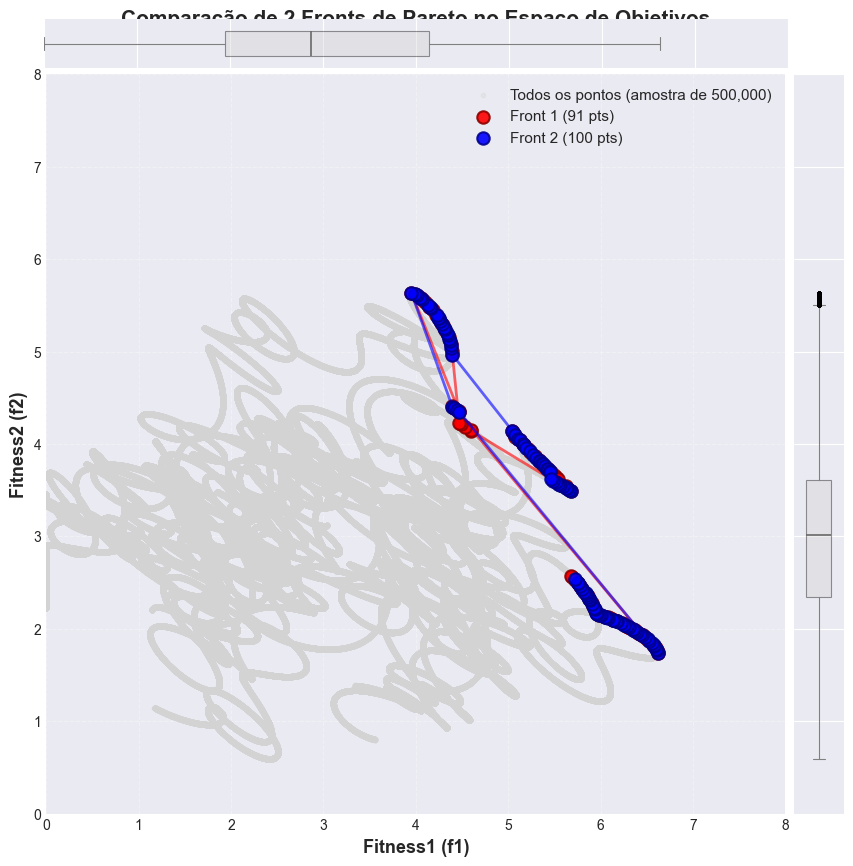

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 91
   • Pontos no front encontrado: 100

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.012509
   • Desvio Padrão:            0.011824

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.061799
   • Mediana:                  0.009180

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


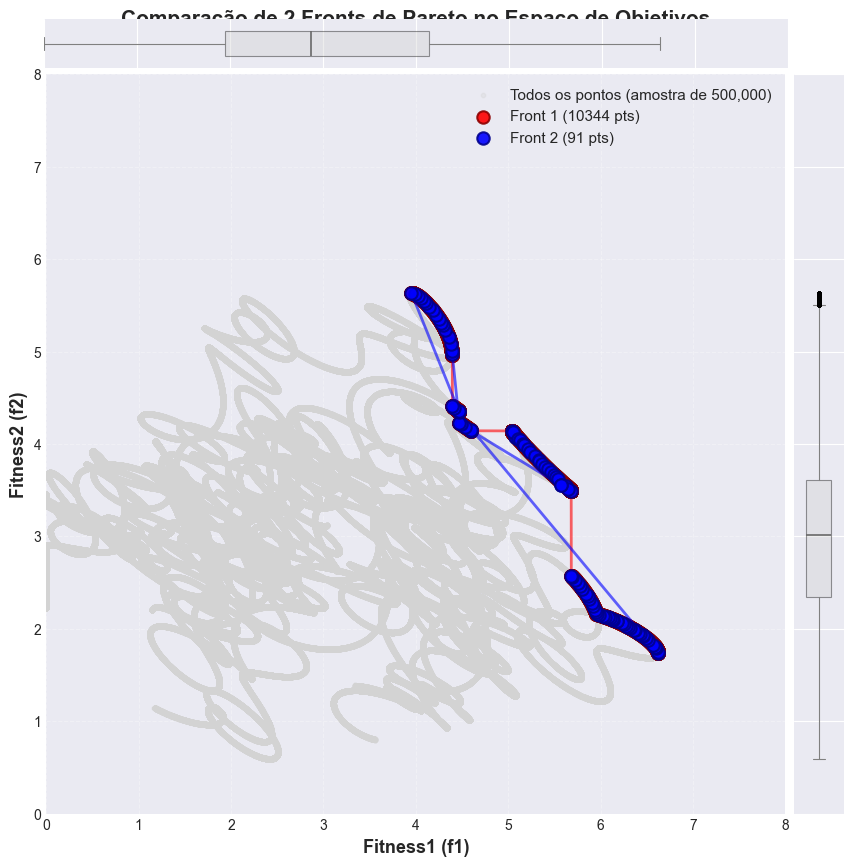

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 10,344
   • Pontos no front encontrado: 91

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.000948
   • Desvio Padrão:            0.004852

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.031406
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


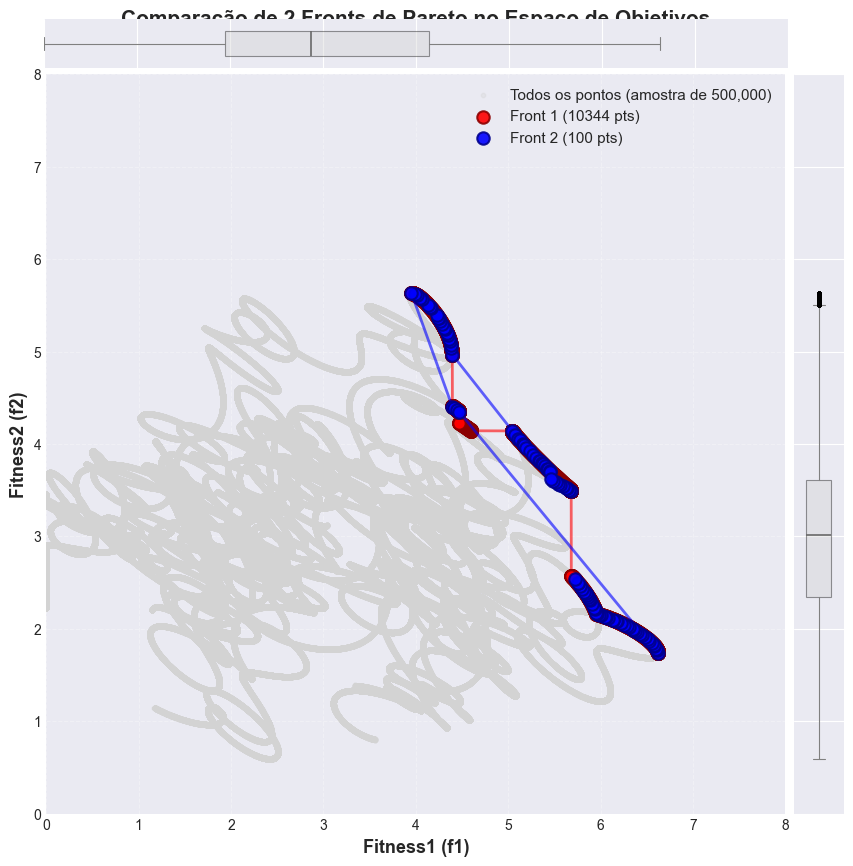

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 10,344
   • Pontos no front encontrado: 100

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.003356
   • Desvio Padrão:            0.010887

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.060467
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


In [10]:
# experimento
df = df1.copy()
df_pareto_real      = find_pareto_front(df)
df_pareto_my, _, _  = run_my_nsga2(config, df)
df_pareto_moo, _, _ = run_nsga2_pymoo(config, df)

# convergencia entre resultados
#display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_moo])
display_pareto_fronts3(df, [df_pareto_my, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_my, df_pareto_moo)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_pareto_fronts3(df, [df_pareto_real, df_pareto_my])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_pareto_fronts3(df, [df_pareto_real, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_moo)
print_gamma_metric(gamma_results)

### Problema 1. Landscape Previsto

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 318 pontos.
Isso representa 0.0318% do espaço de busca.


100%|██████████| 200/200 [00:13<00:00, 14.51it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 48


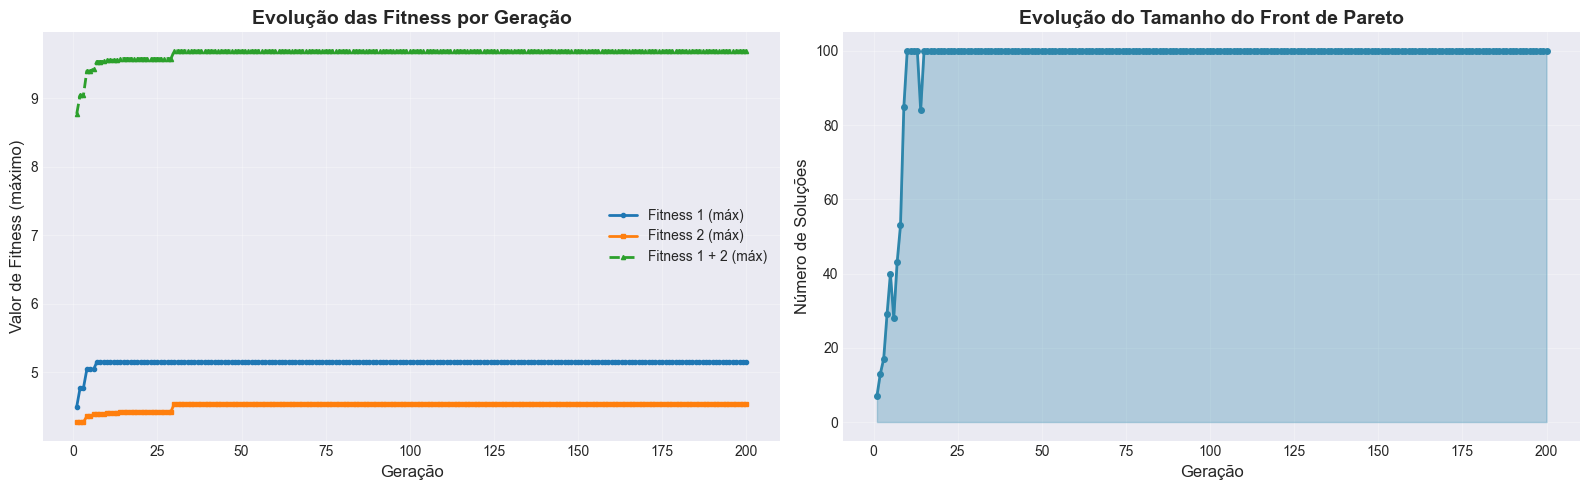


✅ Gráficos de progresso gerados com sucesso!

✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 100


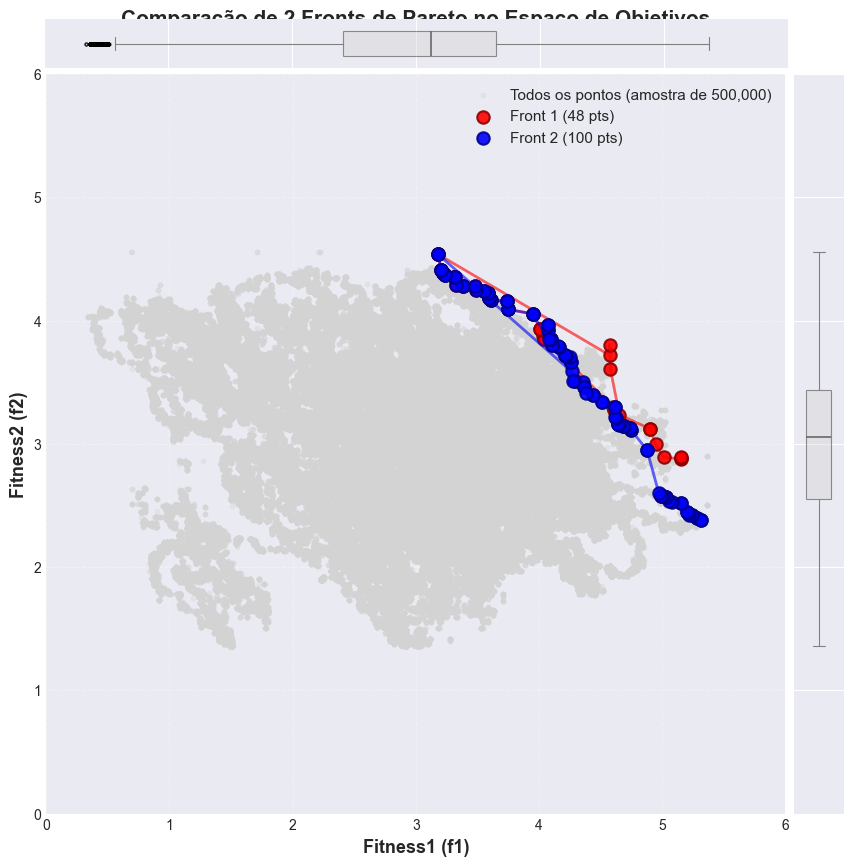

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 48
   • Pontos no front encontrado: 100

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.145419
   • Desvio Padrão:            0.162888

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.517863
   • Mediana:                  0.052505

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


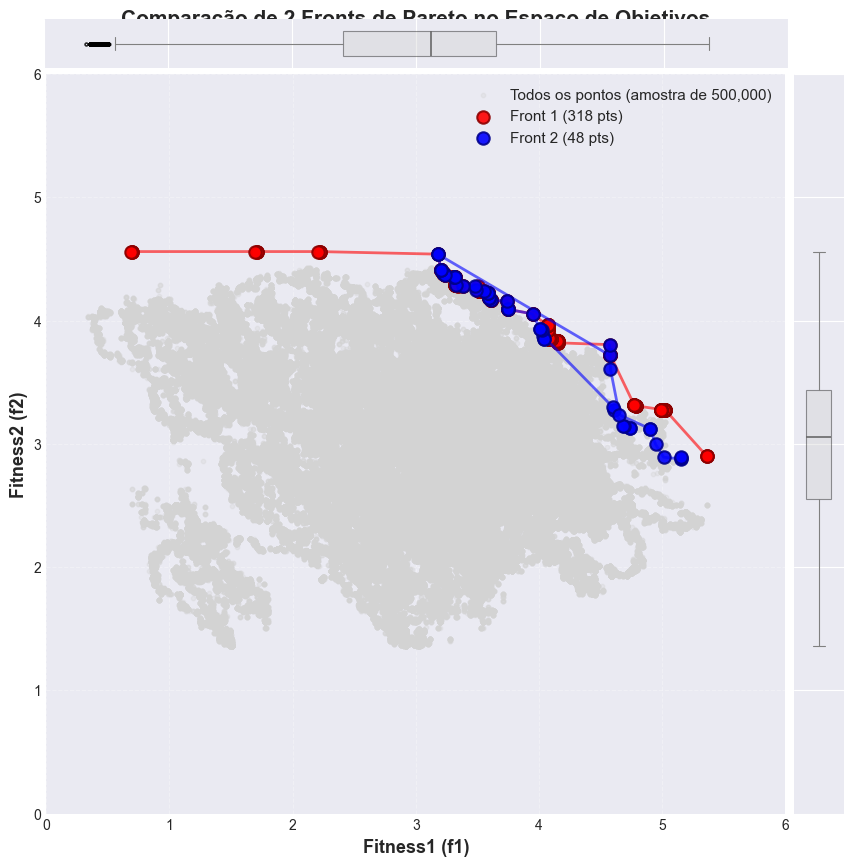

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 318
   • Pontos no front encontrado: 48

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.069236
   • Desvio Padrão:            0.093563

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.349252
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


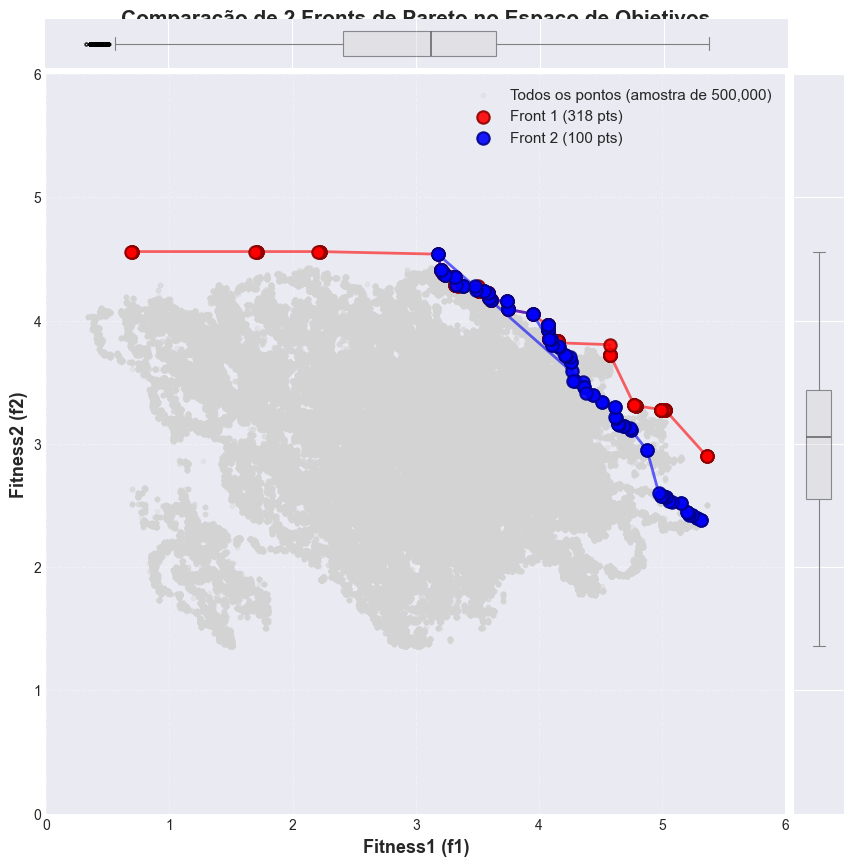

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 318
   • Pontos no front encontrado: 100

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.189225
   • Desvio Padrão:            0.188316

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.518124
   • Mediana:                  0.176160

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


In [11]:
# experimento
df_predicted = df1.copy().drop(columns=['fitness1', 'fitness2'])
df_predicted.rename(columns={'fitness1_c1': 'fitness1', 'fitness2_c1': 'fitness2'}, inplace=True)

df_pareto_surrogate = find_pareto_front(df_predicted)
df_pareto_my, _, _  = run_my_nsga2(config, df_predicted)
df_pareto_moo, _, _ = run_nsga2_pymoo(config, df_predicted)

# convergencia entre resultados
#display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_my, df_pareto_moo])
display_pareto_fronts3(df_predicted, [df_pareto_my, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_my, df_pareto_moo)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_pareto_fronts3(df_predicted, [df_pareto_surrogate, df_pareto_my])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_surrogate, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_pareto_fronts3(df_predicted, [df_pareto_surrogate, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_surrogate, df_pareto_moo)
print_gamma_metric(gamma_results)


### Problema 2. Landscape Real

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 4,416 pontos.
Isso representa 0.4416% do espaço de busca.


100%|██████████| 200/200 [00:13<00:00, 14.40it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 85


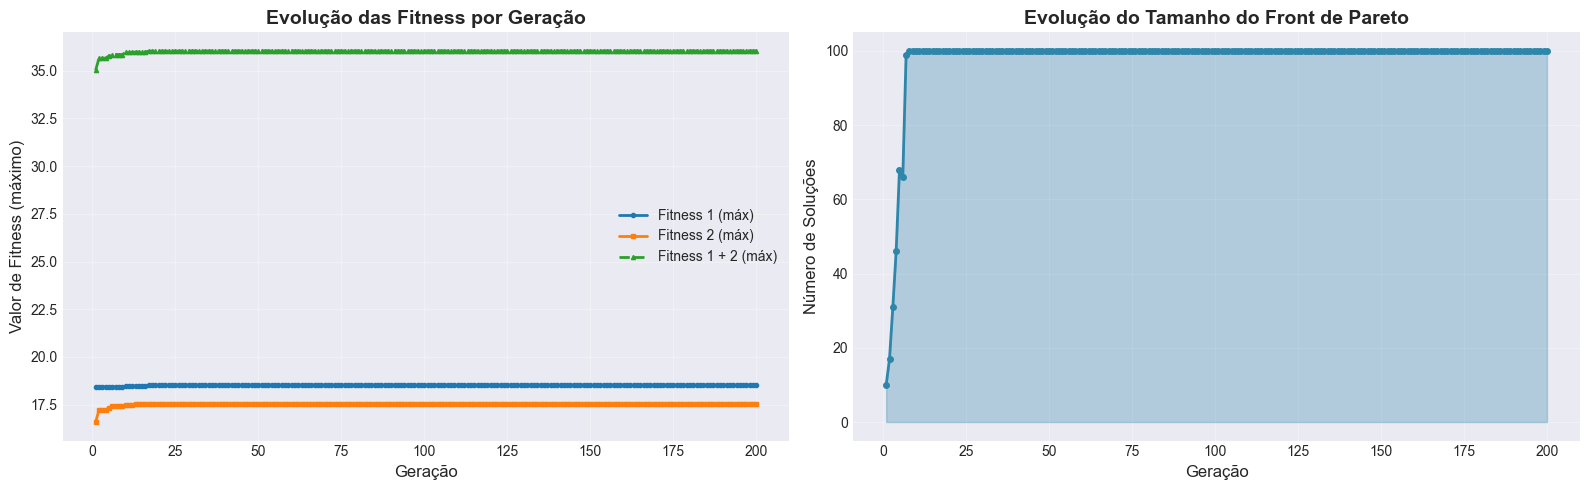


✅ Gráficos de progresso gerados com sucesso!

✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 100


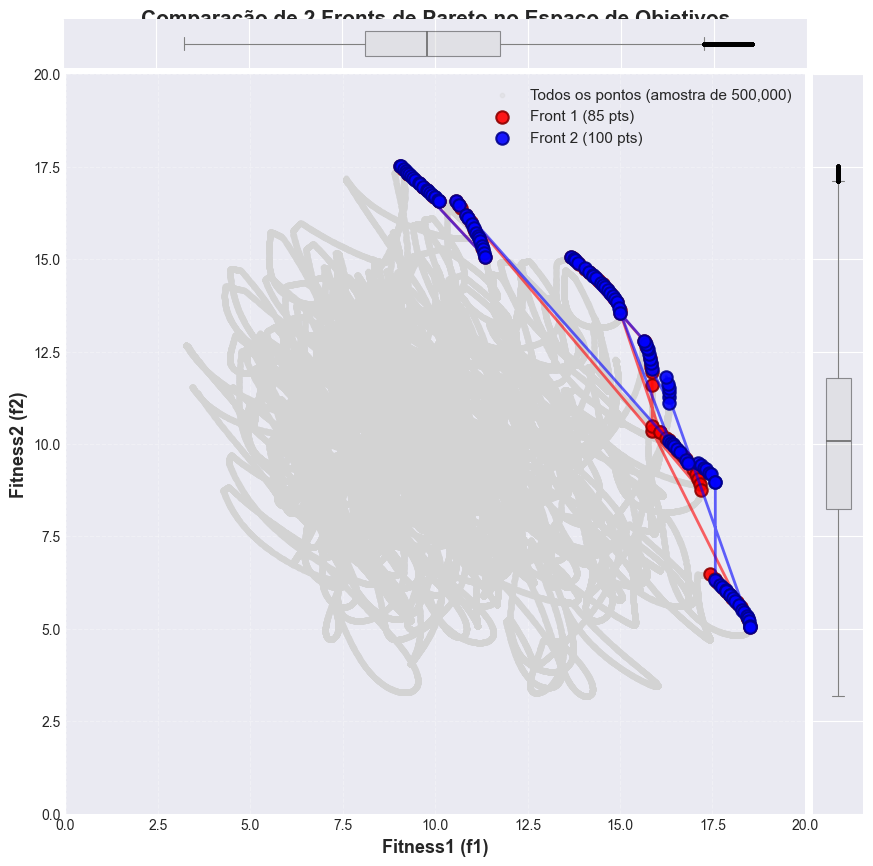

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 85
   • Pontos no front encontrado: 100

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.087995
   • Desvio Padrão:            0.137201

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.674392
   • Mediana:                  0.038094

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


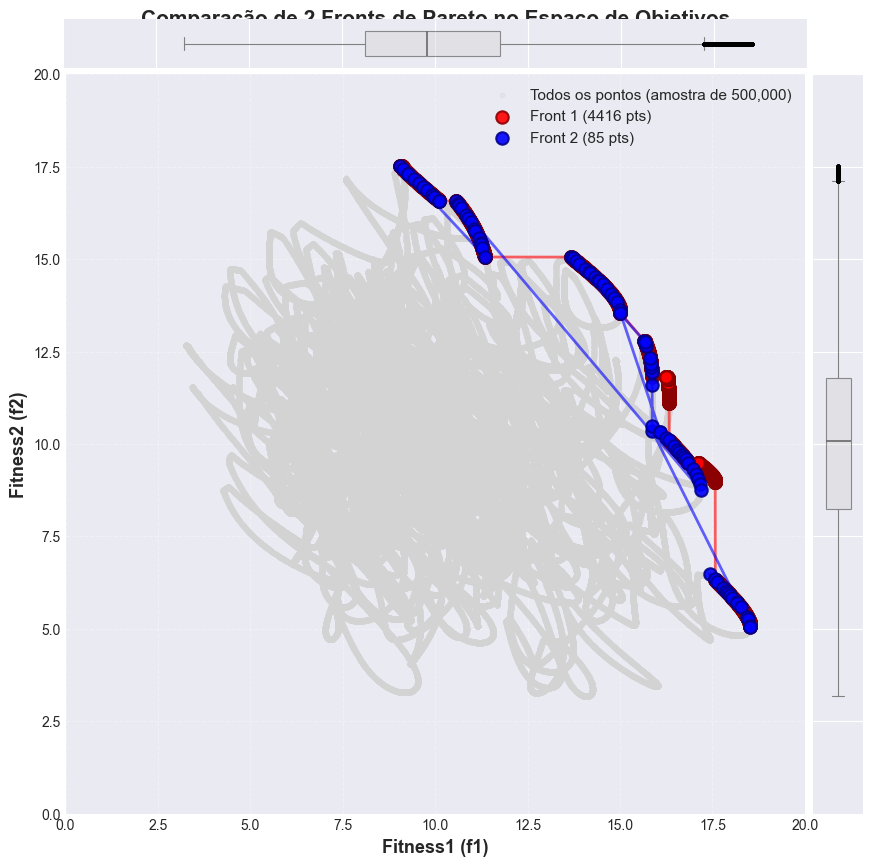

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 4,416
   • Pontos no front encontrado: 85

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.047997
   • Desvio Padrão:            0.128054

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.612767
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


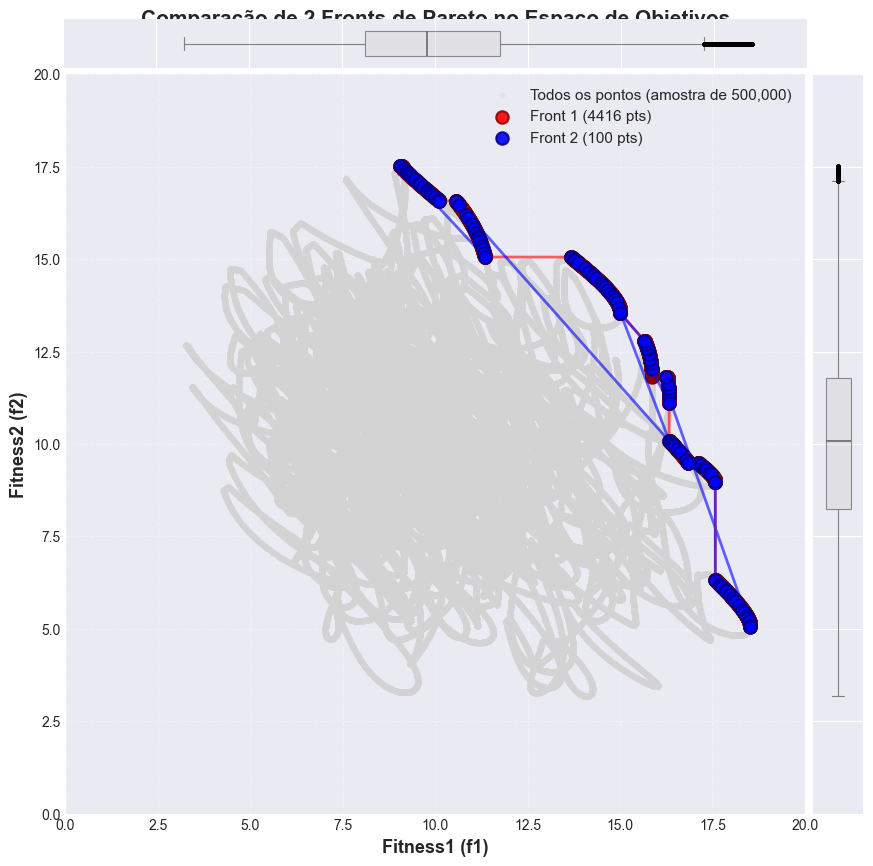

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 4,416
   • Pontos no front encontrado: 100

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.000064
   • Desvio Padrão:            0.000545

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.005398
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


In [12]:
# experimento
df = df2.copy()
df_pareto_real      = find_pareto_front(df)
df_pareto_my, _, _  = run_my_nsga2(config, df)
df_pareto_moo, _, _ = run_nsga2_pymoo(config, df)

# convergencia entre resultados
#display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_moo])
display_pareto_fronts3(df, [df_pareto_my, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_my, df_pareto_moo)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_pareto_fronts3(df, [df_pareto_real, df_pareto_my])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_pareto_fronts3(df, [df_pareto_real, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_moo)
print_gamma_metric(gamma_results)

### Problema 2. Landscape Previsto

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 220 pontos.
Isso representa 0.0220% do espaço de busca.


100%|██████████| 200/200 [00:14<00:00, 13.76it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 43


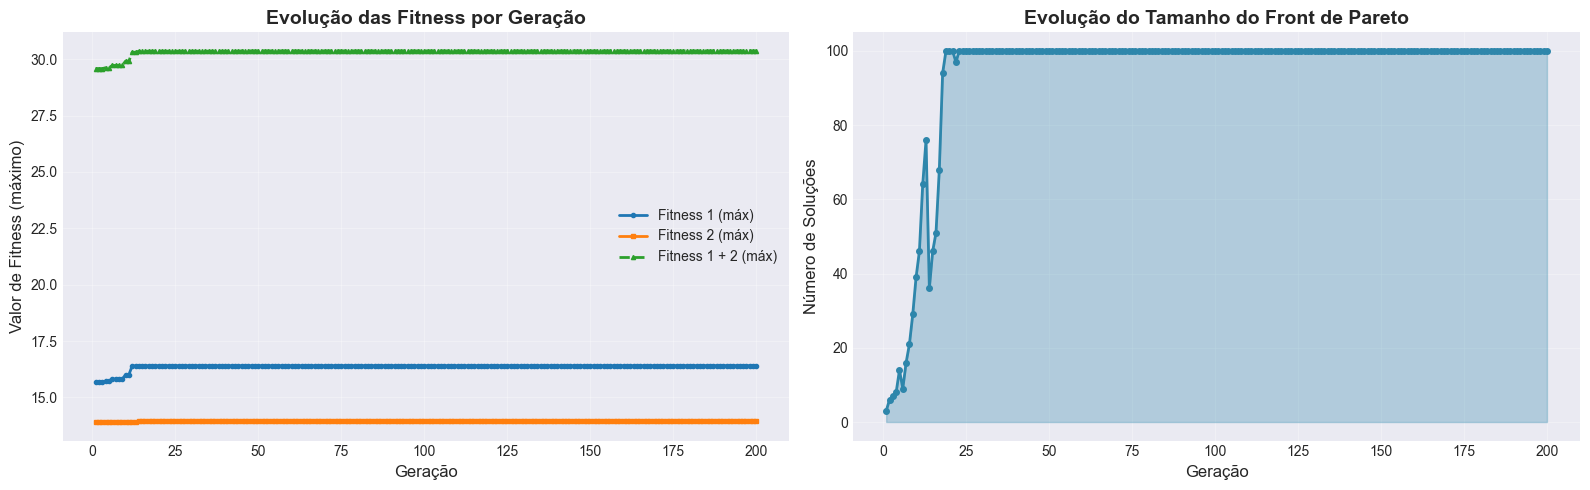


✅ Gráficos de progresso gerados com sucesso!

✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 100


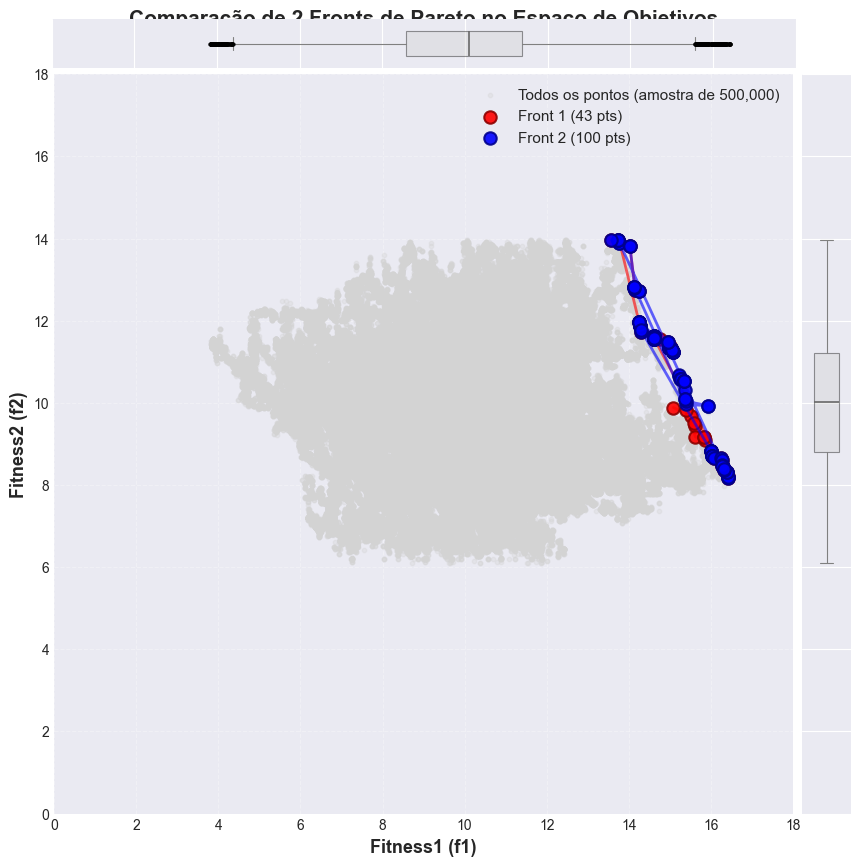

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 43
   • Pontos no front encontrado: 100

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.088761
   • Desvio Padrão:            0.204492

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.692467
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


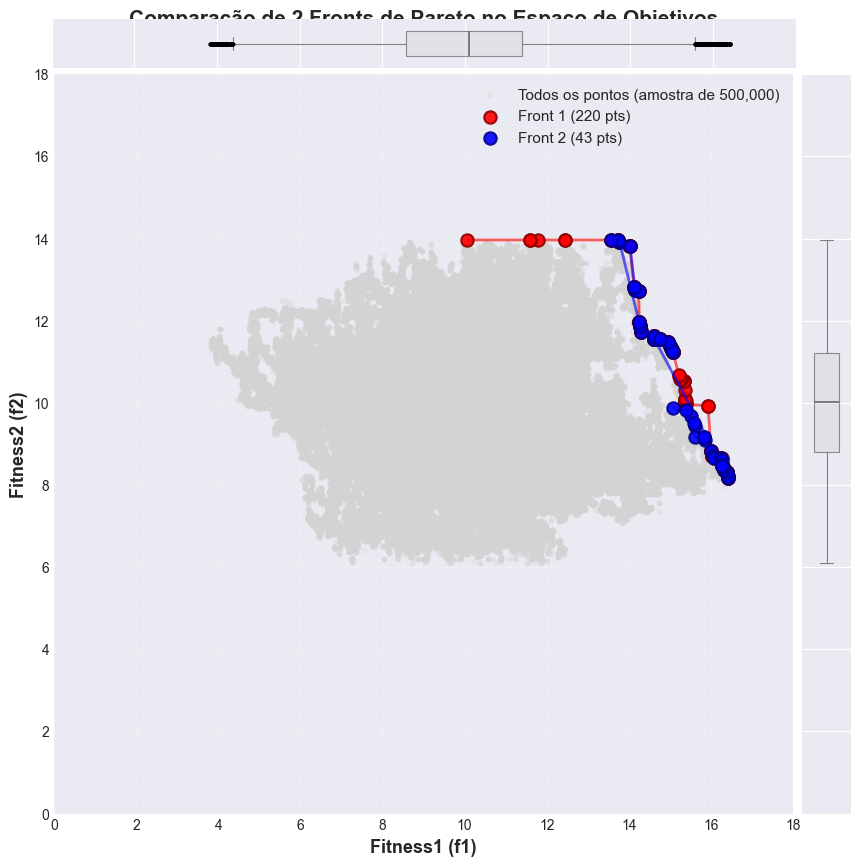

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 220
   • Pontos no front encontrado: 43

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.080941
   • Desvio Padrão:            0.164372

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.555836
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


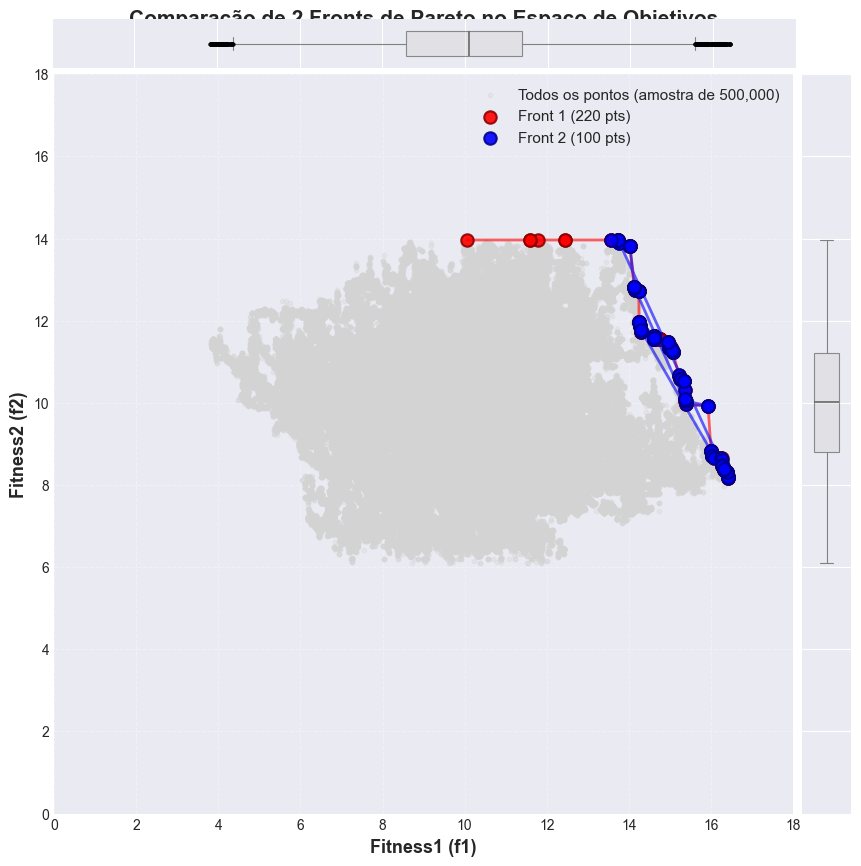

MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 220
   • Pontos no front encontrado: 100

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.003805
   • Desvio Padrão:            0.011623

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.000000
   • Máxima:                   0.052715
   • Mediana:                  0.000000

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


In [13]:
# experimento
df_predicted = df2.copy().drop(columns=['fitness1', 'fitness2'])
df_predicted.rename(columns={'fitness1_c1': 'fitness1', 'fitness2_c1': 'fitness2'}, inplace=True)

df_pareto_surrogate = find_pareto_front(df_predicted)
df_pareto_my, _, _  = run_my_nsga2(config, df_predicted)
df_pareto_moo, _, _ = run_nsga2_pymoo(config, df_predicted)

# convergencia entre resultados
#display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_my, df_pareto_moo])
display_pareto_fronts3(df_predicted, [df_pareto_my, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_my, df_pareto_moo)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_pareto_fronts3(df_predicted, [df_pareto_surrogate, df_pareto_my])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_surrogate, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_pareto_fronts3(df_predicted, [df_pareto_surrogate, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_surrogate, df_pareto_moo)
print_gamma_metric(gamma_results)


# Outros

### Comparando funções de crossover e mutação com Pymoo 
* (não são similares)